<a href="https://colab.research.google.com/github/noviardhana/Rice-Image-Classification/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Klasifikasi Gambar: Rice Image Dataset
- **Nama:** Tegas Gagas Impian Prahita Noviardhana
- **Email:** tegasgagasimpian@gmail.com
- **ID Dicoding:** noviardhana

## Import Semua Packages/Library yang Digunakan

In [1]:
# Library yang sering digunakan
!uv pip install -q tensorflowjs

import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Libraries untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io, img_as_ubyte
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

# Libraries untuk pembangunan model
import keras
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
import tensorflowjs as tfjs
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import Input, InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Mencetak versi TensorFlow yang sedang digunakan
print(tf.__version__)

2.19.0


## Data Preparation

### Data Loading

Using Colab cache for faster access to the 'rice-image-dataset' dataset.
Path to dataset files: /kaggle/input/rice-image-dataset


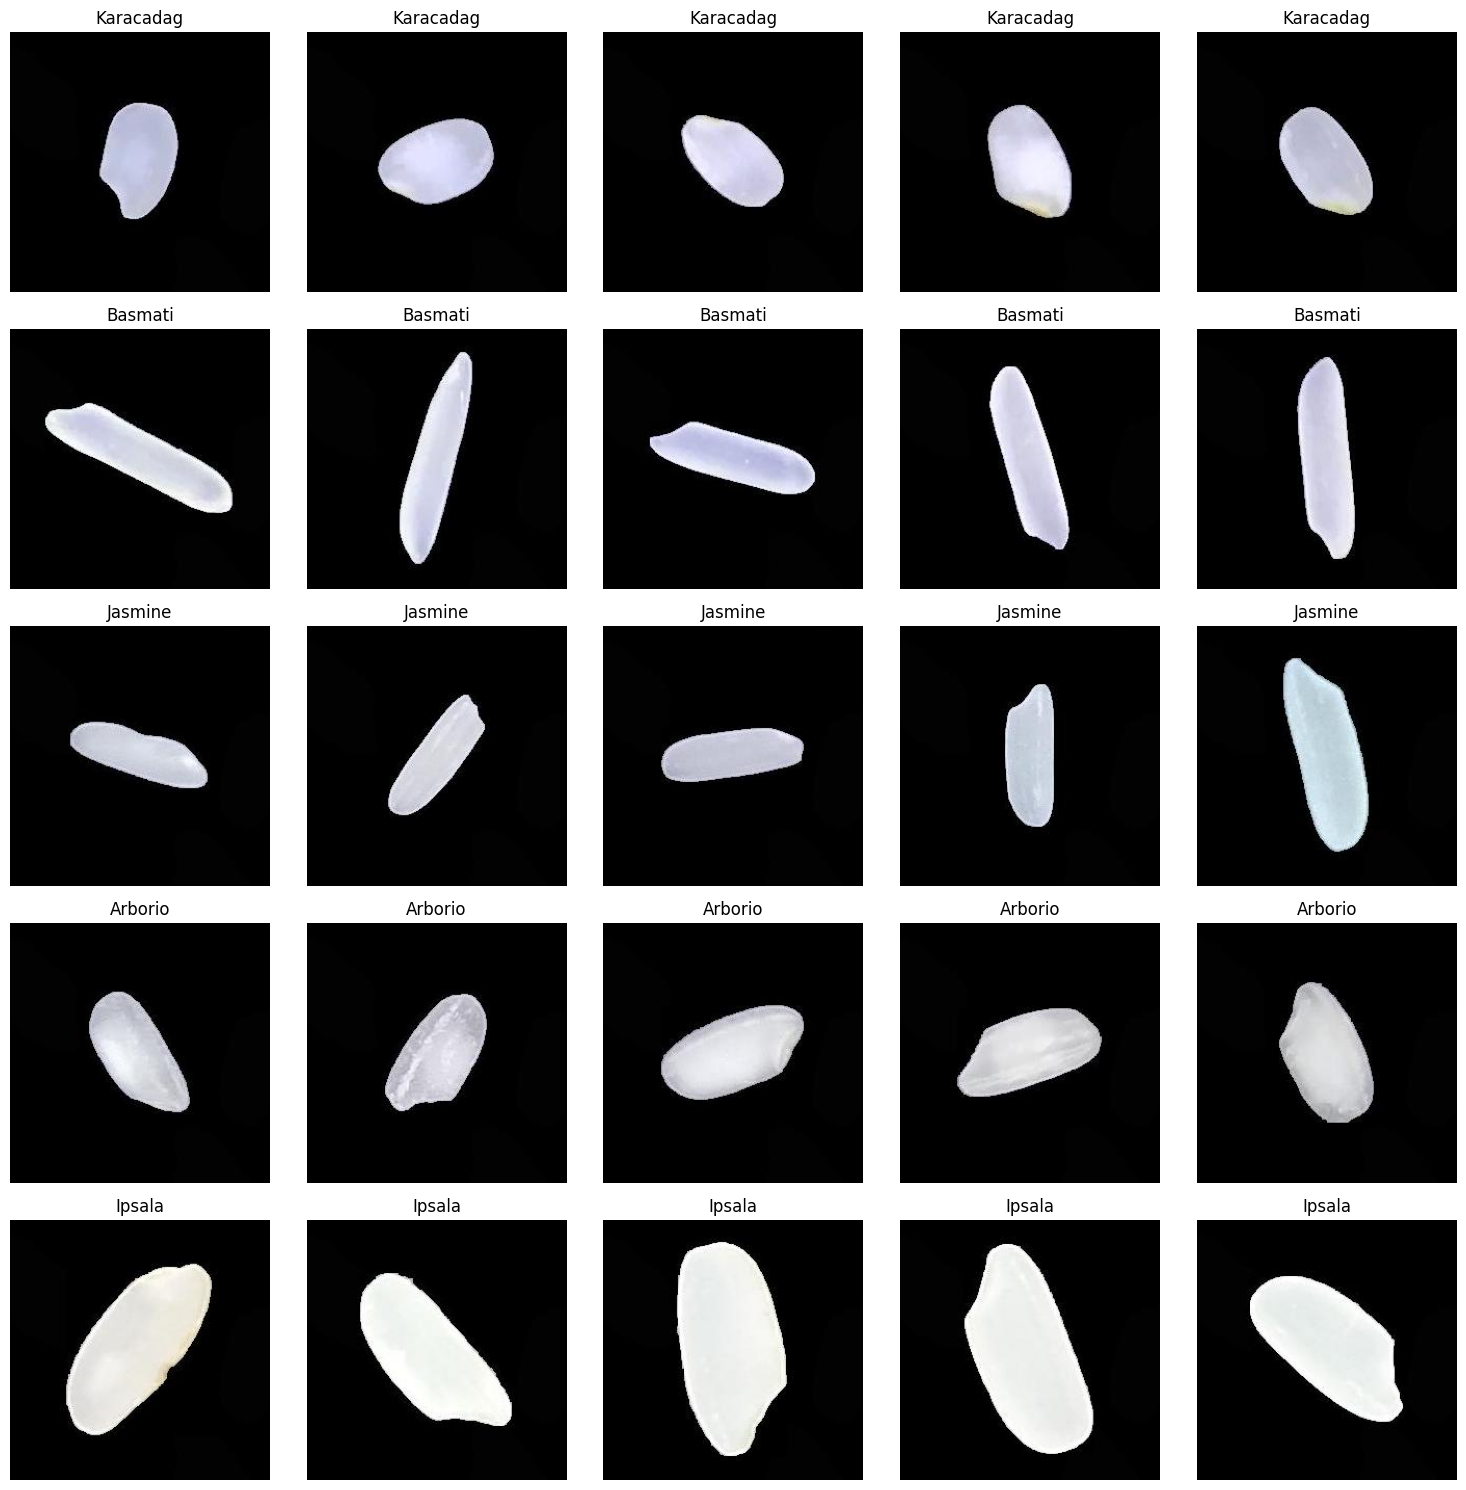

In [2]:
# 1. Mengunduh dataset menggunakan kagglehub
path = kagglehub.dataset_download("muratkokludataset/rice-image-dataset")
print("Path to dataset files:", path)

# Konversi variabel string 'path' menjadi objek Path agar bisa diproses dengan cepat
base_path = Path(path)

# 2. Membuat dictionary kelas & file gambarnya sekaligus
exts = {'.jpg', '.jpeg', '.png'}
rice_images = {d.name: [f for f in d.iterdir() if f.suffix.lower() in exts]
               for d in base_path.rglob('*') if d.is_dir()}
rice_images = {k: v for k, v in rice_images.items() if v} # Buang folder yang kosong

# 3. Visualisasi 5 gambar acak per kelas
num_classes = len(rice_images)
fig, axs = plt.subplots(num_classes, 5, figsize=(15, 3 * num_classes))

for i, (class_name, images) in enumerate(rice_images.items()):
    for j, img_path in enumerate(random.sample(images, 5)):
        ax = axs[i, j] if num_classes > 1 else axs[j]
        ax.imshow(Image.open(img_path).convert("RGB"))
        ax.set_title(class_name)
        ax.axis('off')

fig.tight_layout()
plt.show()

Membaca seluruh file gambar, mohon tunggu...
Total gambar ditemukan: 75000
                                                 path              file_name  \
0  /kaggle/input/rice-image-dataset/Rice_Image_Da...  Karacadag (11154).jpg   
1  /kaggle/input/rice-image-dataset/Rice_Image_Da...   Karacadag (8058).jpg   
2  /kaggle/input/rice-image-dataset/Rice_Image_Da...   Karacadag (5150).jpg   
3  /kaggle/input/rice-image-dataset/Rice_Image_Da...   Karacadag (8267).jpg   
4  /kaggle/input/rice-image-dataset/Rice_Image_Da...   Karacadag (8747).jpg   

      labels  
0  Karacadag  
1  Karacadag  
2  Karacadag  
3  Karacadag  
4  Karacadag  


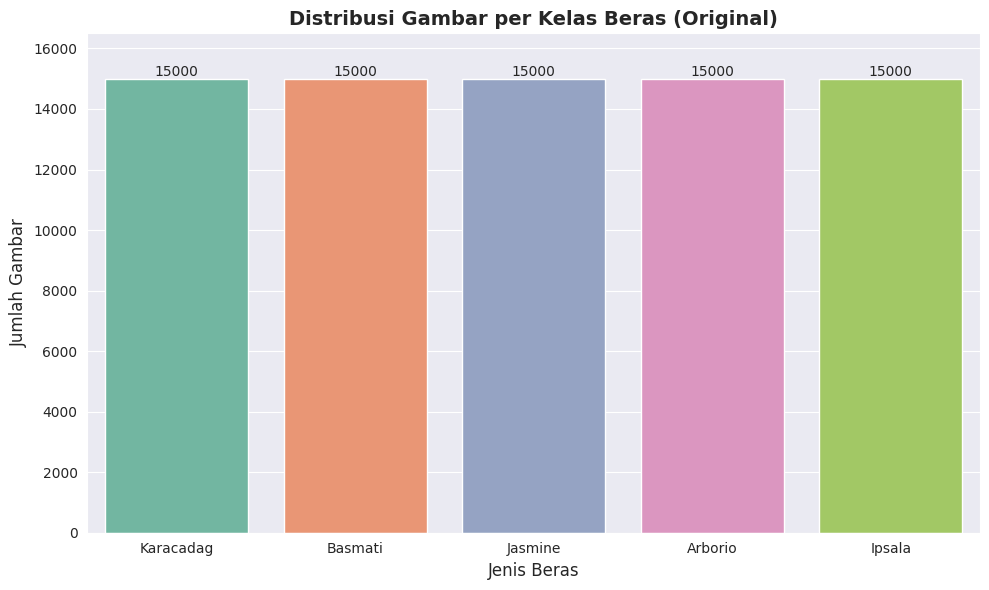

In [3]:
# 1. Definisikan path sumber (asumsi base_path berupa string atau objek Path)
rice_path = Path(base_path)
print("Membaca seluruh file gambar, mohon tunggu...")

# 2. Dapatkan path, nama file, dan label sekaligus dengan list comprehension (Sangat Cepat & Ringkas)
exts = {'.jpg', '.jpeg', '.png'}
image_files = [f for f in rice_path.rglob('*') if f.suffix.lower() in exts]

# 3. Simpan langsung sebagai DataFrame
distribution_df = pd.DataFrame({
    "path": [str(f) for f in image_files],
    "file_name": [f.name for f in image_files],
    "labels": [f.parent.name for f in image_files] # f.parent.name mengambil nama folder kelas
})

print(f"Total gambar ditemukan: {len(distribution_df)}\n", distribution_df.head())

# 4. Plot distribusi gambar di setiap kelas
plt.figure(figsize=(10, 6))
sns.set_style("darkgrid")
ax = sns.countplot(data=distribution_df, x='labels', hue='labels', palette='Set2', legend=False)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribusi Gambar per Kelas Beras (Original)', fontsize=14, fontweight='bold')
plt.xlabel('Jenis Beras', fontsize=12)
plt.ylabel('Jumlah Gambar', fontsize=12)

# Menambah sedikit ruang di atas grafik agar angka tertinggi tidak terpotong (opsional)
plt.ylim(0, distribution_df['labels'].value_counts().max() * 1.1)

plt.tight_layout()
plt.show()

### Data Preprocessing

In [4]:
# 1. Fungsi Augmentasi Murni
# Logika konversi dan resize sudah kita pindahkan ke dalam looping utama
def anticlockwise_rotation(img):
    return rotate(img, random.randint(0, 180))

def clockwise_rotation(img):
    return rotate(img, -random.randint(0, 180))

def flip_up_down(img):
    return np.flipud(img)

def add_brightness(img):
    return adjust_gamma(img, gamma=0.5, gain=1)

def blur_image(img):
    return cv2.GaussianBlur(img, (9, 9), 0)

def sheared(img):
    return warp(img, AffineTransform(shear=0.2), mode="wrap")

def warp_shift(img):
    return warp(img, AffineTransform(translation=(0, 40)), mode="wrap")

transformations = [
    anticlockwise_rotation, clockwise_rotation, flip_up_down,
    add_brightness, blur_image, sheared, warp_shift
]

In [5]:
daftar_kelas = ["Arborio", "Basmati", "Ipsala", "Jasmine", "Karacadag"]
images_to_generate = 2000
base_path = Path("/kaggle/input/rice-image-dataset")
output_base = Path("/content/rice_dataset_augmented")

print("Memulai proses augmentasi massal...\n")

for cls in daftar_kelas:
    print(f"=== Memproses Kelas: {cls} ===")

    # 1. Cari folder dan gambar dengan cepat menggunakan fungsi next()
    img_dir = next(base_path.rglob(cls), None)
    images = [f for f in img_dir.glob('*') if f.suffix.lower() in {'.jpg', '.jpeg', '.png'}] if img_dir else []

    if not images:
        print(f"Peringatan: Folder/gambar {cls} tidak ditemukan. Melewati.")
        continue

    # Operator Walrus (:=) membuat dan menyimpan direktori dalam satu baris
    (aug_dir := output_base / f"{cls}_augmented").mkdir(parents=True, exist_ok=True)

    # 2. Proses Augmentasi Gambar
    for i in range(1, images_to_generate + 1):
        img_path = random.choice(images)
        try:
            img = io.imread(img_path)

            # Buang alpha channel (jika RGBA) dan lakukan resize langsung dalam 1 baris
            img = cv2.resize(img[..., :3] if img.ndim == 3 and img.shape[-1] == 4 else img, (224, 224))

            # Terapkan efek acak langsung di dalam loop
            for func in random.sample(transformations, random.randint(1, len(transformations))):
                if img.dtype in (np.float64, np.float32): img = img_as_ubyte(img)
                img = func(img)

            # 3. Finalisasi & Save
            if img.dtype in (np.float64, np.float32): img = img_as_ubyte(img)
            img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR) if img.ndim == 3 else img

            cv2.imwrite(str(aug_dir / f"{cls}_aug_{i}.jpg"), img)

            if i % 500 == 0:
                print(f"[{cls}] Berhasil {i}/{images_to_generate} gambar...")

        except Exception as e:
            print(f"Gagal memproses '{img_path.name}': {e}")

print("\nSeluruh proses augmentasi untuk semua kelas beras telah berhasil dan tersimpan!")

Memulai proses augmentasi massal...

=== Memproses Kelas: Arborio ===
[Arborio] Berhasil 500/2000 gambar...
[Arborio] Berhasil 1000/2000 gambar...
[Arborio] Berhasil 1500/2000 gambar...
[Arborio] Berhasil 2000/2000 gambar...
=== Memproses Kelas: Basmati ===
[Basmati] Berhasil 500/2000 gambar...
[Basmati] Berhasil 1000/2000 gambar...
[Basmati] Berhasil 1500/2000 gambar...
[Basmati] Berhasil 2000/2000 gambar...
=== Memproses Kelas: Ipsala ===
[Ipsala] Berhasil 500/2000 gambar...
[Ipsala] Berhasil 1000/2000 gambar...
[Ipsala] Berhasil 1500/2000 gambar...
[Ipsala] Berhasil 2000/2000 gambar...
=== Memproses Kelas: Jasmine ===
[Jasmine] Berhasil 500/2000 gambar...
[Jasmine] Berhasil 1000/2000 gambar...
[Jasmine] Berhasil 1500/2000 gambar...
[Jasmine] Berhasil 2000/2000 gambar...
=== Memproses Kelas: Karacadag ===
[Karacadag] Berhasil 500/2000 gambar...
[Karacadag] Berhasil 1000/2000 gambar...
[Karacadag] Berhasil 1500/2000 gambar...
[Karacadag] Berhasil 2000/2000 gambar...

Seluruh proses au

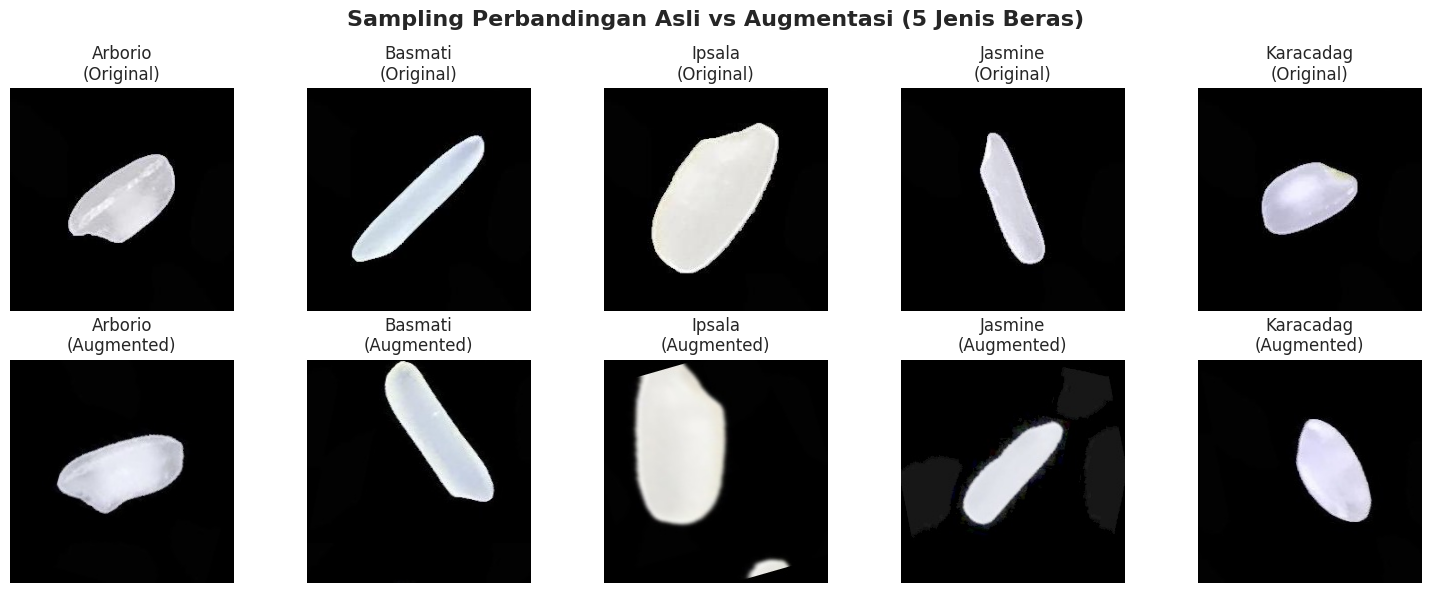

In [6]:
# 1. Setup Data & Path
daftar_kelas = ["Arborio", "Basmati", "Ipsala", "Jasmine", "Karacadag"]
base_path = Path("/kaggle/input/rice-image-dataset")
base_aug_path = Path("/content/rice_dataset_augmented")

# 2. Siapkan Kanvas
fig, axs = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Sampling Perbandingan Asli vs Augmentasi (5 Jenis Beras)", fontsize=16, fontweight='bold')

# Fungsi anonim (lambda) untuk mengambil 1 gambar acak dari sebuah folder
get_rand_img = lambda folder: random.choice([f for f in folder.iterdir() if f.suffix.lower() in {'.jpg', '.jpeg', '.png'}])

# 3. Looping Utama per Kelas
for i, target_class in enumerate(daftar_kelas):

    pencarian_folder = list(base_path.rglob(target_class))
    if not pencarian_folder:
        print(f"Peringatan: Folder '{target_class}' tidak ditemukan di {base_path}")
        continue

    path_asli = pencarian_folder[0]

    # Struktur data untuk baris: (Path Folder, Label Teks)
    sumber_data = [
        (path_asli, "Original"),
        (base_aug_path / f"{target_class}_augmented", "Augmented")
    ]

    # Looping untuk baris 0 (Original) dan baris 1 (Augmented)
    for row, (folder_path, label) in enumerate(sumber_data):
        try:
            img_file = get_rand_img(folder_path)

            axs[row, i].imshow(Image.open(img_file))
            axs[row, i].set_title(f"{target_class}\n({label})", fontsize=12)
            axs[row, i].axis('off')
        except Exception as e:
            print(f"Gagal memuat gambar untuk {target_class} ({label}): {e}")
            axs[row, i].axis('off') # Sembunyikan axis jika gagal

plt.tight_layout()
plt.subplots_adjust(top=0.85) # Menyesuaikan ruang judul utama
plt.show()

Sedang memproses data, mohon tunggu...
Total gambar ditemukan: 10000
                                                 path             file_name  \
0  /content/rice_dataset_augmented/Jasmine_augmen...  Jasmine_aug_1107.jpg   
1  /content/rice_dataset_augmented/Jasmine_augmen...   Jasmine_aug_619.jpg   
2  /content/rice_dataset_augmented/Jasmine_augmen...  Jasmine_aug_1616.jpg   
3  /content/rice_dataset_augmented/Jasmine_augmen...   Jasmine_aug_227.jpg   
4  /content/rice_dataset_augmented/Jasmine_augmen...   Jasmine_aug_217.jpg   

              labels  
0  Jasmine_augmented  
1  Jasmine_augmented  
2  Jasmine_augmented  
3  Jasmine_augmented  
4  Jasmine_augmented  


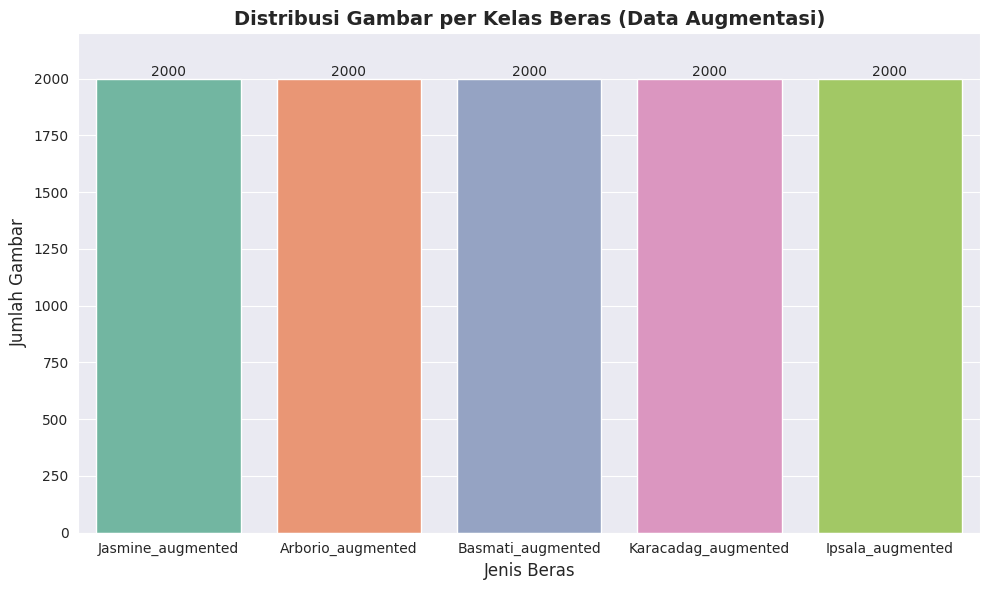

In [7]:
# 1. Definisikan path menggunakan pathlib
rice_path_augm = Path("/content/rice_dataset_augmented")
print("Sedang memproses data, mohon tunggu...")

# 2. Dapatkan data dengan list comprehension (Jauh lebih cepat dari os.walk)
exts = {'.jpg', '.jpeg', '.png'}
image_files = [f for f in rice_path_augm.rglob('*') if f.suffix.lower() in exts]

# 3. Masukkan langsung ke dalam DataFrame
distribution_df = pd.DataFrame({
    "path": [str(f) for f in image_files],
    "file_name": [f.name for f in image_files],
    "labels": [f.parent.name for f in image_files] # Mengambil nama folder langsung
})

print(f"Total gambar ditemukan: {len(distribution_df)}\n", distribution_df.head())

# 4. Plot distribusi gambar di setiap kelas
plt.figure(figsize=(10, 6))
sns.set_style("darkgrid")
ax = sns.countplot(data=distribution_df, x='labels', hue='labels', palette='Set2', legend=False)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribusi Gambar per Kelas Beras (Data Augmentasi)', fontsize=14, fontweight='bold')
plt.xlabel('Jenis Beras', fontsize=12)
plt.ylabel('Jumlah Gambar', fontsize=12)

# Menambah sedikit ruang di atas grafik agar angka tertinggi tidak terpotong (opsional)
plt.ylim(0, distribution_df['labels'].value_counts().max() * 1.1)

plt.tight_layout()
plt.show()

#### Split Dataset

In [8]:
path_awal = Path("/content/dataset_awal")
path_final = Path("/content/Dataset-Final")

# Hapus folder beserta seluruh isinya jika sudah ada
if path_awal.exists():
    shutil.rmtree(path_awal)
    print("Folder dataset_awal lama berhasil dibersihkan!")

if path_final.exists():
    shutil.rmtree(path_final)
    print("Folder Dataset-Final lama berhasil dibersihkan!")

In [9]:
# 1. Setup Path & Parameter (Deklarasi sebaris)
final_path, rice_path, augm_path = Path("/content/dataset_awal"), Path("/kaggle/input/rice-image-dataset"), Path("/content/rice_dataset_augmented")
daftar_kelas = ["Arborio", "Basmati", "Ipsala", "Jasmine", "Karacadag"]
exts = {'.jpg', '.jpeg', '.png'}
total, t_asli = 5000, 3500

print(f"Memulai pembuatan dataset final ({total} gambar/kelas)...\n")

for cls in daftar_kelas:
    (dest_dir := final_path / cls).mkdir(parents=True, exist_ok=True)

    # 2. Pencarian File Instan: rglob("{cls}/*") otomatis mencari isi folder dari kedalaman manapun
    orig_files = [f for f in rice_path.rglob(f"{cls}/*") if f.suffix.lower() in exts]
    aug_files = [f for f in augm_path.rglob(f"{cls}_augmented/*") if f.suffix.lower() in exts]

    # 3. Sampling Cerdas: min()
    sel_orig = random.sample(orig_files, min(t_asli, len(orig_files)))
    sel_aug = random.sample(aug_files, min(total - len(sel_orig), len(aug_files)))

    # Gabungkan dan acak urutannya
    selected = sel_orig + sel_aug
    random.shuffle(selected)

    print(f"[{cls}] Tersalin: {len(selected)} ({len(sel_orig)} Asli | {len(sel_aug)} Augmentasi)")

    # 4. Copy (Loop sebaris)
    for f in tq(selected, desc=cls, leave=False): shutil.copy2(f, dest_dir / f.name)

print(f"\nSelesai! Data final siap di: {final_path}")

Memulai pembuatan dataset final (5000 gambar/kelas)...

[Arborio] Tersalin: 5000 (3500 Asli | 1500 Augmentasi)


Arborio:   0%|          | 0/5000 [00:00<?, ?it/s]

[Basmati] Tersalin: 5000 (3500 Asli | 1500 Augmentasi)


Basmati:   0%|          | 0/5000 [00:00<?, ?it/s]

[Ipsala] Tersalin: 5000 (3500 Asli | 1500 Augmentasi)


...

[Jasmine] Tersalin: 5000 (3500 Asli | 1500 Augmentasi)


Jasmine:   0%|          | 0/5000 [00:00<?, ?it/s]

[Karacadag] Tersalin: 5000 (3500 Asli | 1500 Augmentasi)


Karacadag:   0%|          | 0/5000 [00:00<?, ?it/s]


Selesai! Data final siap di: /content/dataset_awal


In [10]:
src, dst = Path("/content/dataset_awal"), Path("/content/Dataset-Final")
print("Memproses dataset (Train 70% | Val 10% | Test 20%)...")

# 1. Ekstraksi Data
df = pd.DataFrame([{"path": f, "label": f.parent.name, "is_aug": '_aug_' in f.name.lower()}
                   for f in src.rglob('*') if f.suffix.lower() in {'.jpg', '.jpeg', '.png'}])

# 2. Split Ori (2 Tahap) & Gabung Data Augmentasi
ori = df[~df.is_aug]
sisa, test = train_test_split(ori, test_size=0.2, random_state=300, stratify=ori['label'])
train, val = train_test_split(sisa, test_size=0.125, random_state=300, stratify=sisa['label'])

df_all = pd.concat([train.assign(set='train'), df[df.is_aug].assign(set='train'), val.assign(set='valid'), test.assign(set='test')])
print(f"{'='*40}\nDistribusi Data:\n{df_all.groupby(['set', 'label']).size()}\n{'='*40}")

# 3. Setup Folder & Copy File
[(dst / s / l).mkdir(parents=True, exist_ok=True) for s in df_all['set'].unique() for l in df['label'].unique()]

for r in tq(df_all.itertuples(index=False), total=len(df_all), desc="Menyusun Dataset"):
    # Cukup periksa eksistensi folder/file tujuan, lebih hemat waktu komputasi
    if not (d := dst / r.set / r.label / Path(r.path).name).exists():
        shutil.copy2(r.path, d)

Memproses dataset (Train 70% | Val 10% | Test 20%)...
Distribusi Data:
set    label    
test   Arborio       700
       Basmati       700
       Ipsala        700
       Jasmine       700
       Karacadag     700
train  Arborio      3950
       Basmati      3950
       Ipsala       3950
       Jasmine      3950
       Karacadag    3950
valid  Arborio       350
       Basmati       350
       Ipsala        350
       Jasmine       350
       Karacadag     350
dtype: int64


Menyusun Dataset:   0%|          | 0/25000 [00:00<?, ?it/s]

In [11]:
# 1. Definisikan path utama
dataset_path = Path("/content/Dataset-Final")
daftar_kelas = ["Arborio", "Basmati", "Ipsala", "Jasmine", "Karacadag"]

# 2. Iterasi untuk ketiga jenis set data
for split in ['train', 'valid', 'test']:
    print(f"\n=== JUMLAH DATA {split.upper()} ===")

    for kelas in daftar_kelas:
        folder_path = dataset_path / split / kelas

        if folder_path.exists():
            files = list(folder_path.iterdir())
            total = len(files)

            jml_aug = sum(1 for f in files if '_aug_' in f.name.lower())
            jml_ori = total - jml_aug

            print(f"Total {kelas:<10} : {total:<5} ({jml_ori} Asli | {jml_aug} Augmentasi)")
        else:
            print(f"Total {kelas:<10} : Folder tidak ditemukan")


=== JUMLAH DATA TRAIN ===
Total Arborio    : 3950  (2450 Asli | 1500 Augmentasi)
Total Basmati    : 3950  (2450 Asli | 1500 Augmentasi)
Total Ipsala     : 3950  (2450 Asli | 1500 Augmentasi)
Total Jasmine    : 3950  (2450 Asli | 1500 Augmentasi)
Total Karacadag  : 3950  (2450 Asli | 1500 Augmentasi)

=== JUMLAH DATA VALID ===
Total Arborio    : 350   (350 Asli | 0 Augmentasi)
Total Basmati    : 350   (350 Asli | 0 Augmentasi)
Total Ipsala     : 350   (350 Asli | 0 Augmentasi)
Total Jasmine    : 350   (350 Asli | 0 Augmentasi)
Total Karacadag  : 350   (350 Asli | 0 Augmentasi)

=== JUMLAH DATA TEST ===
Total Arborio    : 700   (700 Asli | 0 Augmentasi)
Total Basmati    : 700   (700 Asli | 0 Augmentasi)
Total Ipsala     : 700   (700 Asli | 0 Augmentasi)
Total Jasmine    : 700   (700 Asli | 0 Augmentasi)
Total Karacadag  : 700   (700 Asli | 0 Augmentasi)


In [12]:
def print_images_resolution(directory):
    base_path = Path(directory)
    print(f"Menganalisis resolusi gambar di: {base_path}\n")

    global_sizes = set()
    total_images = 0
    exts = {'.jpg', '.jpeg', '.png'}

    # Iterasi HANYA pada direktori (folder)
    for folder in [d for d in base_path.iterdir() if d.is_dir()]:
        images = [f for f in folder.iterdir() if f.suffix.lower() in exts]
        total_images += len(images)

        print(f"\n [{folder.name}] Jumlah gambar: {len(images)}")

        # Mengekstrak ukuran gambar (Image.open sangat cepat karena hanya membaca header/metadata)
        folder_sizes = set()
        for img_path in tq(images, desc=f"Mengecek {folder.name}", leave=False):
            try:
                with Image.open(img_path) as img:
                    folder_sizes.add(img.size)
            except Exception as e:
                print(f"Gagal membaca {img_path.name}: {e}")

        # Gabungkan set lokal ke set global (Lebih efisien daripada menambahkannya satu per satu di loop atas)
        global_sizes.update(folder_sizes)

        # Unpacking tuple (w, h) langsung di dalam loop
        for w, h in folder_sizes:
            print(f"  - {w} x {h} piksel")
        print("-" * 40)

    print(f"\n TOTAL KESELURUHAN GAMBAR: {total_images}")
    print("Seluruh variasi resolusi dalam dataset ini:")
    for w, h in global_sizes:
        print(f"  - {w} x {h} piksel")

# Cukup arahkan ke folder yang ingin dicek
print_images_resolution("/content/Dataset-Final/train")

Menganalisis resolusi gambar di: /content/Dataset-Final/train


 [Karacadag] Jumlah gambar: 3950


Mengecek Karacadag:   0%|          | 0/3950 [00:00<?, ?it/s]

  - 224 x 224 piksel
  - 250 x 250 piksel
----------------------------------------

 [Basmati] Jumlah gambar: 3950


Mengecek Basmati:   0%|          | 0/3950 [00:00<?, ?it/s]

  - 224 x 224 piksel
  - 250 x 250 piksel
----------------------------------------

 [Arborio] Jumlah gambar: 3950


...

  - 224 x 224 piksel
  - 250 x 250 piksel
----------------------------------------

 [Jasmine] Jumlah gambar: 3950


Mengecek Jasmine:   0%|          | 0/3950 [00:00<?, ?it/s]

  - 224 x 224 piksel
  - 250 x 250 piksel
----------------------------------------

 [Ipsala] Jumlah gambar: 3950


Mengecek Ipsala:   0%|          | 0/3950 [00:00<?, ?it/s]

  - 224 x 224 piksel
  - 250 x 250 piksel
----------------------------------------

 TOTAL KESELURUHAN GAMBAR: 19750
Seluruh variasi resolusi dalam dataset ini:
  - 224 x 224 piksel
  - 250 x 250 piksel


## Modelling

In [13]:
# 1. Definisikan Path ke ketiga folder
dataset_path = Path("/content/Dataset-Final")
train_dir = str(dataset_path / 'train')
valid_dir = str(dataset_path / 'valid')
test_dir = str(dataset_path / 'test')

# 2. Inisialisasi Data Generator (Cukup 1 karena semuanya hanya butuh rescale)
datagen = ImageDataGenerator(rescale=1./255)

print("Mempersiapkan Data Generator...")

# 3. Argumen bersama (Hanya yang berbeda dari default Keras)
args = {"target_size": (224, 224)}

# 4. Eksekusi Generator (Arahkan ke folder masing-masing, hapus parameter subset)
train_generator = datagen.flow_from_directory(train_dir, **args)

validation_generator = datagen.flow_from_directory(valid_dir, shuffle=False, **args)

test_generator = datagen.flow_from_directory(test_dir, batch_size=1, shuffle=False, **args)

Mempersiapkan Data Generator...
Found 19750 images belonging to 5 classes.
Found 1750 images belonging to 5 classes.
Found 3500 images belonging to 5 classes.


In [14]:
# Membersihkan sesi Keras di memori
tf.keras.backend.clear_session()

# Inisialisasi model langsung menggunakan list untuk memangkas baris kode
model_awal = Sequential([
    # Input disesuaikan dengan target_size generator sebelumnya (224x224)
    Input(shape=(224, 224, 3)),

    # Block Convolutional 1
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D((2, 2)),

    # Block Convolutional 2
    Conv2D(32, (4, 4), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D((2, 2)),

    # Block Convolutional 3
    Conv2D(32, (7, 7), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D((2, 2)),

    # Fully Connected Layer
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Mencegah overfitting
    Dense(64, activation='relu'),
    Dropout(0.3),

    # Output Layer (5 jenis beras -> Softmax)
    Dense(5, activation='softmax')
])

# Compile Model
model_awal.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Tampilkan ringkasan arsitektur
model_awal.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 32)     │        50,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,287,877 (12.54 MB)

 Trainable params: 3,287,685 (12.54 MB)

 Non-trainable params: 192 (768.00 B)

In [15]:
# 1. Membuat fitur pemberhentian otomatis (Early Stopping)
early_stop = EarlyStopping(
    monitor='val_loss',        # Memantau nilai loss pada data validasi
    patience=10,               # Toleransi 10 epoch tanpa perbaikan sebelum dihentikan
    restore_best_weights=True  # Otomatis menggunakan bobot (weights) model terbaik
)

print("Memulai pelatihan model...")

# 2. Proses Pelatihan (Training) Model
history_awal = model_awal.fit(
    train_generator,
    epochs=30,  # Batas maksimal, akan berhenti otomatis jika tidak ada kemajuan
    validation_data=validation_generator,
    callbacks=[early_stop]
)

Memulai pelatihan model...
Epoch 1/30
618/618 ━━━━━━━━━━━━━━━━━━━━ 54s 72ms/step - accuracy: 0.5515 - loss: 1.3200 - val_accuracy: 0.7320 - val_loss: 0.7076
Epoch 2/30
618/618 ━━━━━━━━━━━━━━━━━━━━ 36s 58ms/step - accuracy: 0.6895 - loss: 0.7520 - val_accuracy: 0.6686 - val_loss: 2.5030
Epoch 3/30
618/618 ━━━━━━━━━━━━━━━━━━━━ 36s 59ms/step - accuracy: 0.7280 - loss: 0.6546 - val_accuracy: 0.9640 - val_loss: 0.2220
Epoch 4/30
618/618 ━━━━━━━━━━━━━━━━━━━━ 37s 60ms/step - accuracy: 0.7443 - loss: 0.6050 - val_accuracy: 0.2566 - val_loss: 48.0254
Epoch 5/30
618/618 ━━━━━━━━━━━━━━━━━━━━ 37s 60ms/step - accuracy: 0.7791 - loss: 0.5466 - val_accuracy: 0.9600 - val_loss: 0.1310
Epoch 6/30
618/618 ━━━━━━━━━━━━━━━━━━━━ 37s 60ms/step - accuracy: 0.8086 - loss: 0.4982 - val_accuracy: 0.8811 - val_loss: 0.3080
Epoch 7/30
618/618 ━━━━━━━━━━━━━━━━━━━━ 41s 60ms/step - accuracy: 0.8260 - loss: 0.4636 - val_accuracy: 0.8040 - val_loss: 1.0863
Epoch 8/30
618/618 ━━━━━━━━━━━━━━━━━━━━ 37s 60ms/step - accura

## Evaluasi dan Visualisasi

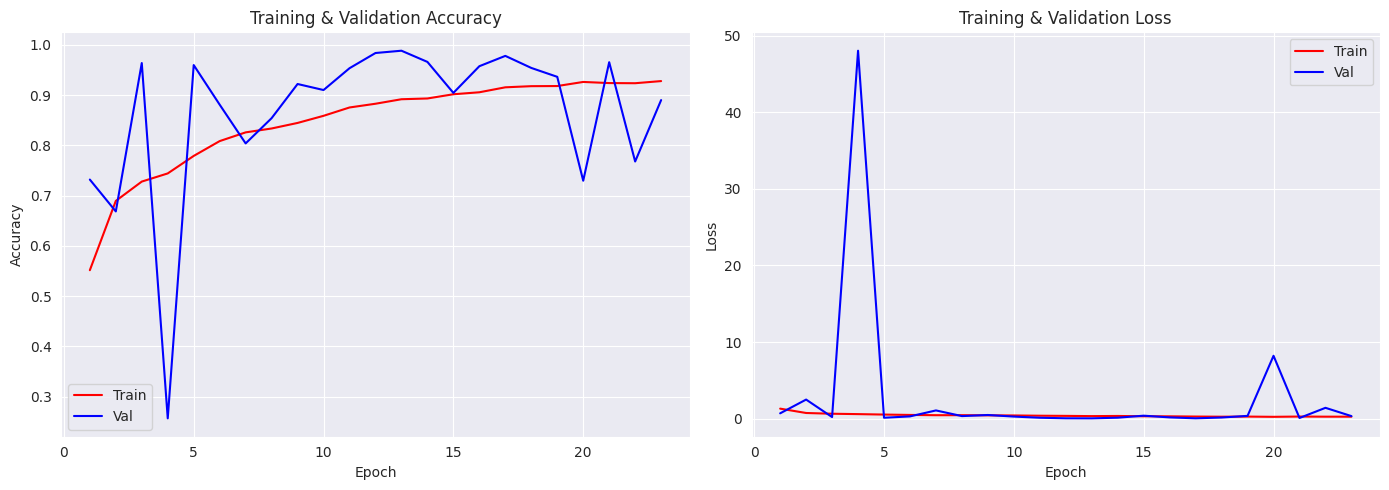

In [16]:
# Ambil dictionary hasil training
h = history_awal.history
epochs = range(1, len(h['accuracy']) + 1)

# Siapkan kanvas berdampingan (1 baris, 2 kolom)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Akurasi (Kiri)
ax1.plot(epochs, h['accuracy'], 'r', label='Train')
ax1.plot(epochs, h['val_accuracy'], 'b', label='Val')
ax1.set(title='Training & Validation Accuracy', xlabel='Epoch', ylabel='Accuracy')
ax1.legend()

# Plot Loss (Kanan)
ax2.plot(epochs, h['loss'], 'r', label='Train')
ax2.plot(epochs, h['val_loss'], 'b', label='Val')
ax2.set(title='Training & Validation Loss', xlabel='Epoch', ylabel='Loss')
ax2.legend()

plt.tight_layout()
plt.show()

Sedang melakukan prediksi pada data uji...
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step


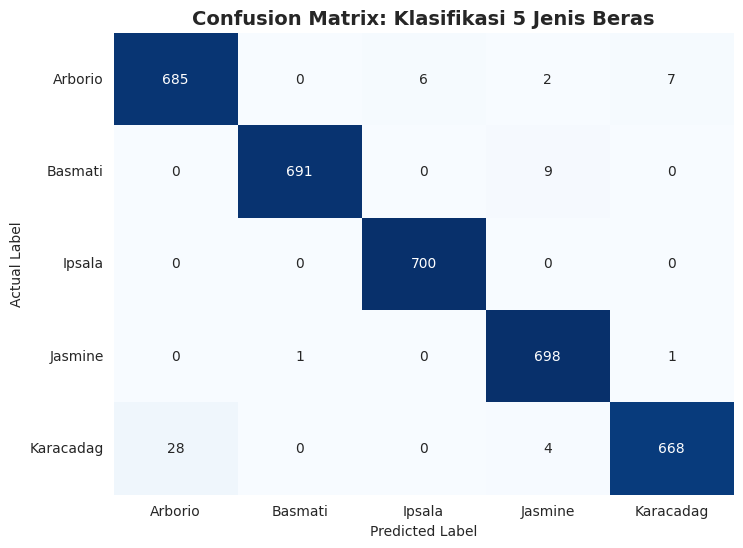


CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Arborio     0.9607    0.9786    0.9696       700
     Basmati     0.9986    0.9871    0.9928       700
      Ipsala     0.9915    1.0000    0.9957       700
     Jasmine     0.9790    0.9971    0.9880       700
   Karacadag     0.9882    0.9543    0.9709       700

    accuracy                         0.9834      3500
   macro avg     0.9836    0.9834    0.9834      3500
weighted avg     0.9836    0.9834    0.9834      3500



In [17]:
# 1. Reset generator & Prediksi langsung ke label kelas (One-liner)
test_generator.reset()
print("Sedang melakukan prediksi pada data uji...")
preds_classes = np.argmax(model_awal.predict(test_generator, verbose=1), axis=1)

# 2. Ambil label asli & nama kelas
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# ==========================================
# 3. Menampilkan Confusion Matrix
# ==========================================
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(true_classes, preds_classes), annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels, cbar=False)
plt.title("Confusion Matrix: Klasifikasi 5 Jenis Beras", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.yticks(rotation=0)
plt.show()

# ==========================================
# 4. Menampilkan Classification Report
# ==========================================
print("\n" + "="*50 + "\nCLASSIFICATION REPORT\n" + "="*50)
print(classification_report(true_classes, preds_classes, target_names=class_labels, digits=4))

## Konversi Model

In [18]:
# 1. Setup Direktori
sub_dir = Path("submission")
for d in ["saved_model", "tflite", "tfjs_model"]:
    (sub_dir / d).mkdir(parents=True, exist_ok=True)

print("Mengekspor model dan membuat dokumen pendukung...")

# 2. Export Format Model
model_awal.export(str(sub_dir / "saved_model"))

tflite_model = tf.lite.TFLiteConverter.from_keras_model(model_awal).convert()
(sub_dir / "tflite" / "model.tflite").write_bytes(tflite_model)
(sub_dir / "tflite" / "label.txt").write_text("\n".join(class_labels))

tfjs.converters.save_keras_model(model_awal, str(sub_dir / "tfjs_model"))


print(f"\n Proses selesai! Seluruh model dan dokumentasi siap di folder: {sub_dir.absolute()}")

Mengekspor model dan membuat dokumen pendukung...
Saved artifact at 'submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  132813616582672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132813616581520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132813526355408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132813526355984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132813526353296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132813526353872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132813651323088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132813651320592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132813526356752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132813526356944: TensorSpec(

failed to lookup keras version from the file,
    this is likely a weight only file

 Proses selesai! Seluruh model dan dokumentasi siap di folder: /content/submission


In [19]:
!pip freeze > submission/requirements.txt

## Inference (Optional)

Memuat model dan menyiapkan inferensi 20 gambar...



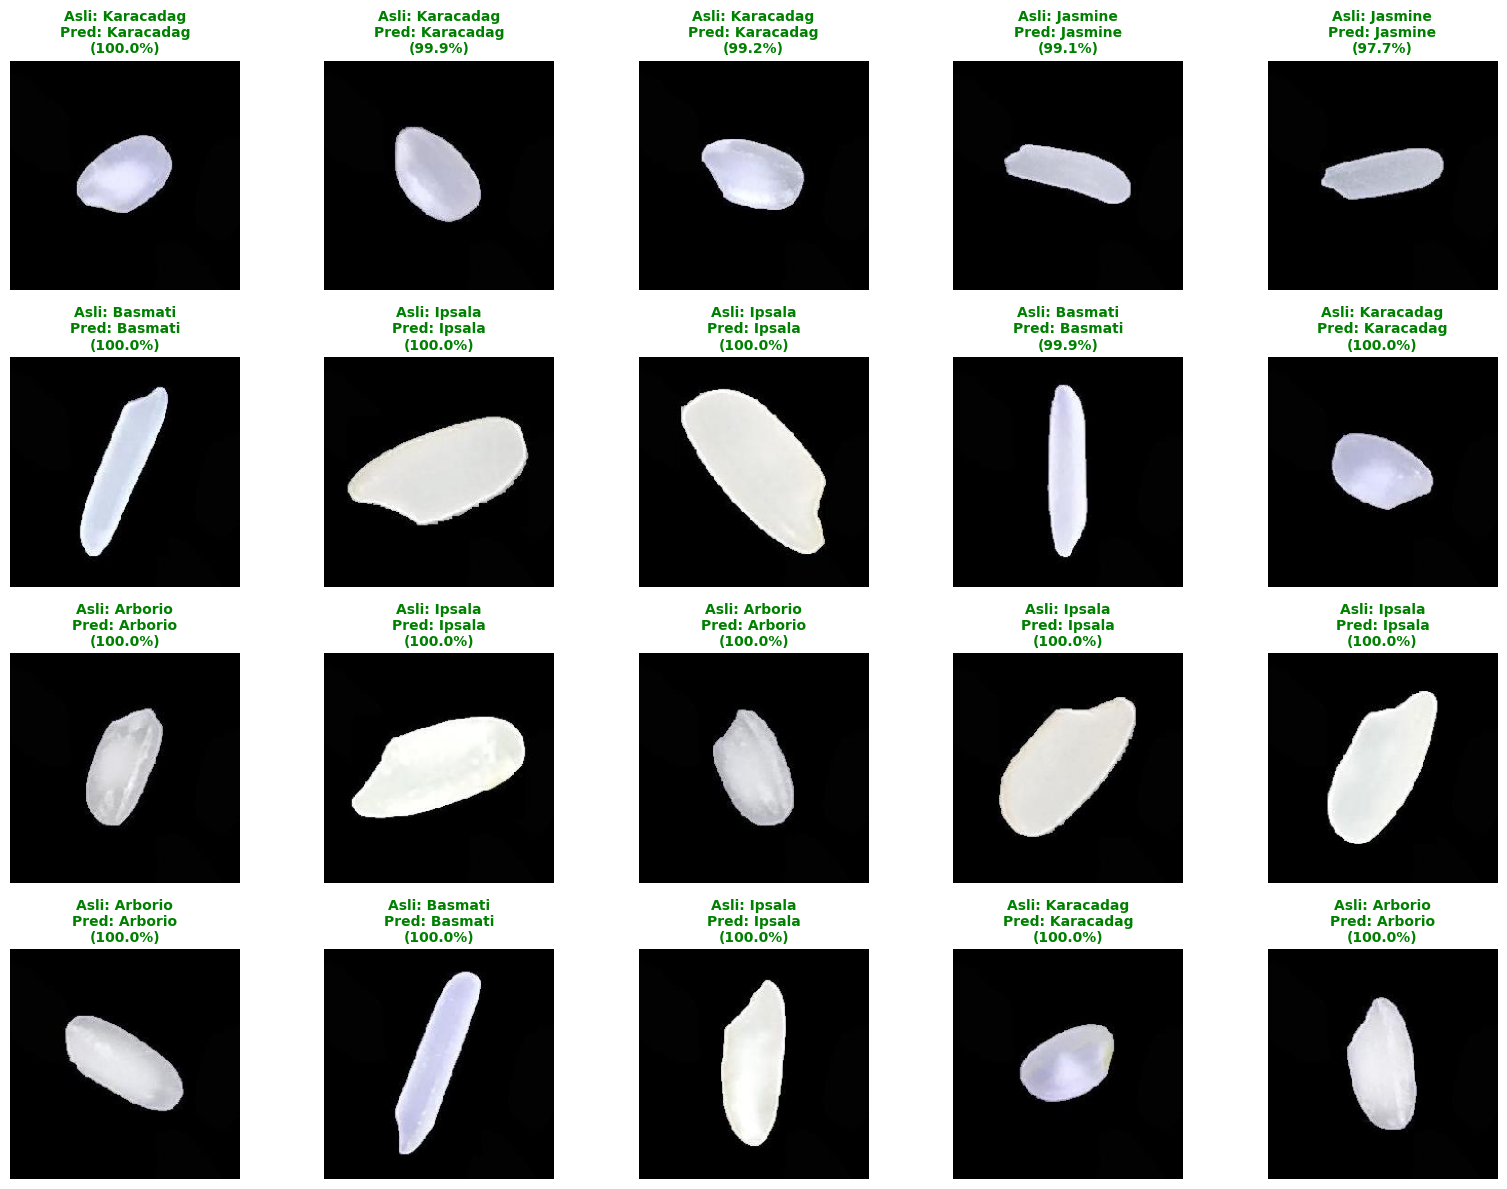

In [20]:
print("Memuat model dan menyiapkan inferensi 20 gambar...\n")
model = tf.keras.layers.TFSMLayer("/content/submission/saved_model", call_endpoint='serve')

valid_dir = Path("/content/Dataset-Final/valid")
classes = sorted([d.name for d in valid_dir.iterdir() if d.is_dir()])
samples = random.sample([f for f in valid_dir.rglob('*') if f.suffix.lower() in {'.jpg', '.png', '.jpeg'}], 20)

fig, axes = plt.subplots(4, 5, figsize=(16, 12))

for ax, p in zip(axes.flat, samples):
    # Rantai proses load, convert, dan rescale dalam satu baris
    img = img_to_array(load_img(p, target_size=(224, 224))) / 255.0

    # Rantai proses expand_dims, cast, inferensi, dan konversi ke NumPy
    pred = np.array(model(tf.cast(np.expand_dims(img, 0), tf.float32)))[0]

    lbl, p_lbl = p.parent.name, classes[np.argmax(pred)]

    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Asli: {lbl}\nPred: {p_lbl}\n({np.max(pred)*100:.1f}%)",
                 color='green' if lbl == p_lbl else 'red', weight='bold', size=10)

plt.tight_layout()
plt.show()

In [21]:
from google.colab import files

print("Mengompres folder submission menjadi ZIP...")
# Membungkus folder /content/submission menjadi submission_final.zip
shutil.make_archive('/content/submission_final', 'zip', '/content/submission')

print("Memulai proses unduhan...")
# Mengunduh file otomatis ke perangkat Anda
files.download('/content/submission_final.zip')

Mengompres folder submission menjadi ZIP...
Memulai proses unduhan...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>